In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy
import glob


# Import and plot data (with FCN)

In [2]:
def process_data(data_txt):
    # Read data
    cols = ['MJD', 'dX', 'sigma_dX', 'dY', 'sigma_dY']
    cols_widths = [(0,11),(12,22),(23,33),(34,44),(45,55)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [3]:
df = process_data('nut_aus.dat')

In [4]:
len(df)

2310

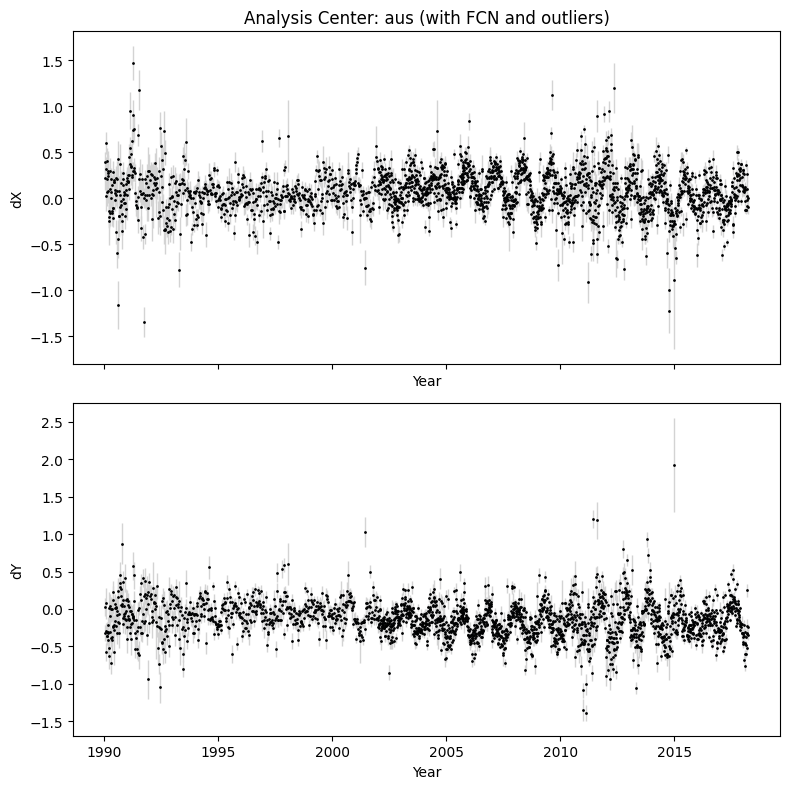

In [5]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dX'], yerr=df['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: aus (with FCN and outliers)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dY'], yerr=df['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

In [6]:
def remove_outliers(df,datatype):
    if datatype == 'dX':
        df_sel = df[['MJD','dX','sigma_dX']].copy()
        datas = 'dX'
        datas_e = 'sigma_dX'
    elif datatype == 'dY':
        df_sel = df[['MJD','dY','sigma_dY']].copy()
        datas = 'dY'
        datas_e = 'sigma_dY'
    else:
        print('Please choose dX/dY data')

    for index, row in df_sel.iterrows():
        data_values = df_sel[(df_sel['MJD'] >= (row['MJD'] - 365)) & (df_sel['MJD'] <= (row['MJD'] + 365))]
        wd = 1/data_values[datas_e].values**2
        mean = np.average(data_values[datas],weights=wd)
        std = np.sqrt(allanself.wvar(data_values[datas].values,wd))
        if abs(row[datas] - mean) > 6*std:
            df_sel.drop(index, inplace = True)
    return df_sel

In [7]:
df_dX = remove_outliers(df,'dX')

In [8]:
len(df_dX)

2309

In [9]:
df_dY = remove_outliers(df,'dY')
len(df_dY)

2308

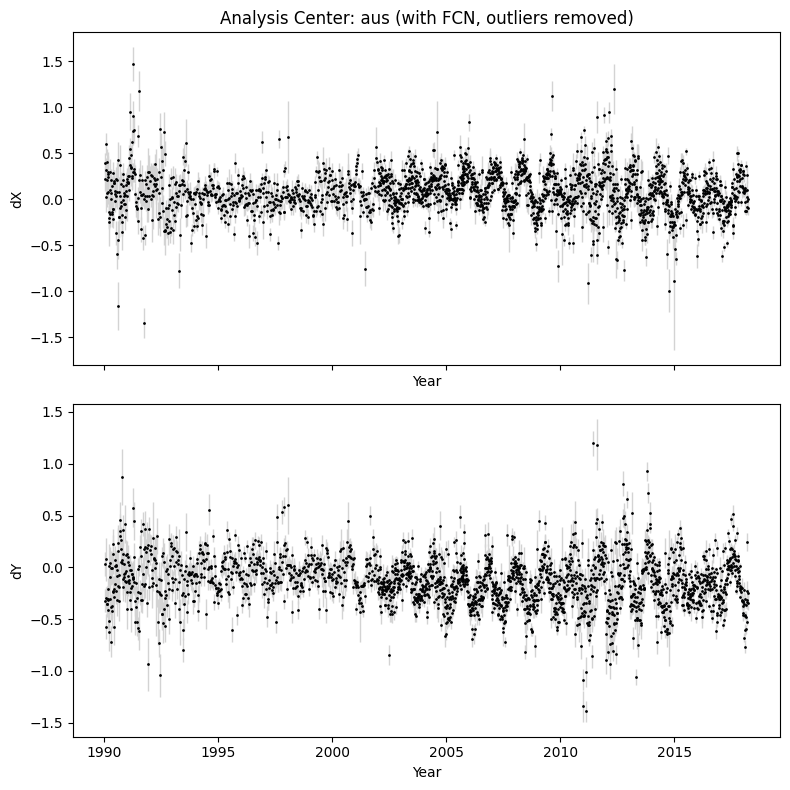

In [10]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - df_dX['MJD']) / 365.242198781, df_dX['dX'], yerr=df_dX['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: aus (with FCN, outliers removed)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - df_dY['MJD']) / 365.242198781, df_dY['dY'], yerr=df_dY['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan std dev - with FNC

In [11]:
%%time
tau_dX, allanstd_dX = allanself.oadev(df_dX['dX'].values,df_dX['MJD'].values,df_dX['sigma_dX'].values)

CPU times: total: 3min 47s
Wall time: 8min 27s


In [12]:
%%time
tau_dY, allanstd_dY = allanself.oadev(df_dY['dY'].values,df_dY['MJD'].values,df_dY['sigma_dY'].values)

CPU times: total: 3min 46s
Wall time: 8min 42s


In [13]:
ci_dX_low, ci_dX_high = allanself.confidence_int(df_dX['dX'].values,df_dX['sigma_dX'].values,allanstd_dX,modified=False,overlapping=True,devtype='allan')

In [14]:
ci_dY_low, ci_dY_high = allanself.confidence_int(df_dY['dY'].values,df_dY['sigma_dY'].values,allanstd_dY,modified=False,overlapping=True,devtype='allan')

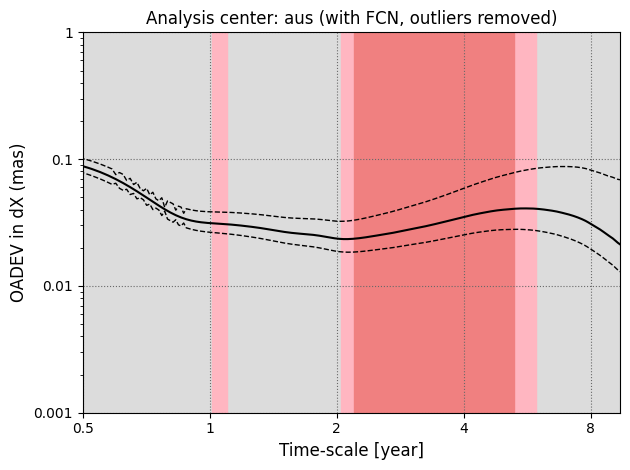

In [15]:
plt.figure()
# Calculate the slopes
slopes_dX = np.diff(np.log10(allanstd_dX)) / np.diff(np.log10(tau_dX))
tau_dX_year = [t/365.242198781 for t in tau_dX]
# Plot allanstd

plt.plot(tau_dX_year,allanstd_dX,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (slopes_dX < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (-0.25 <= slopes_dX) & (slopes_dX <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (slopes_dX > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dX_year, ci_dX_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dX_year, ci_dX_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dX (mas)', fontsize=12)
plt.title('Analysis center: aus (with FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_dX_year))
plt.tight_layout()

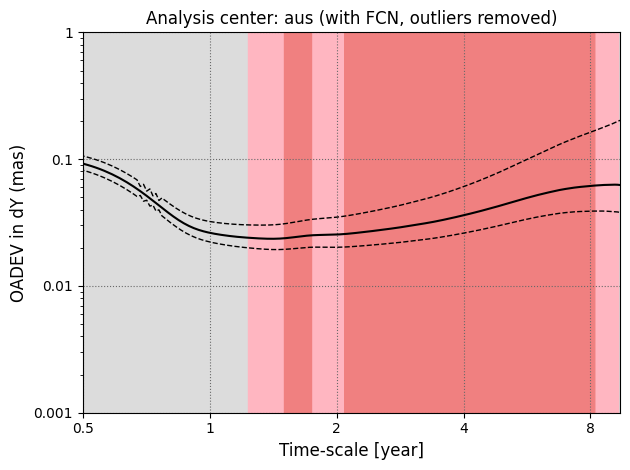

In [16]:
plt.figure()
# Calculate the slopes
slopes_dY = np.diff(np.log10(allanstd_dY)) / np.diff(np.log10(tau_dY))
tau_dY_year = [t/365.242198781 for t in tau_dY]
# Plot allanstd

plt.plot(tau_dY_year,allanstd_dY,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (slopes_dY < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (-0.25 <= slopes_dY) & (slopes_dY <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (slopes_dY > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dY_year, ci_dY_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dY_year, ci_dY_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dY (mas)', fontsize=12)
plt.title('Analysis center: aus (with FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_dY_year))
plt.tight_layout()

# Removing FCN

In [17]:
def process_fcn(fcn_txt):
    # Read data
    cols = ['MJD', 'X', 'Y', 'sigma_X', 'sigma_Y']
    cols_widths = [(0,11),(12,21),(22,31),(32,41),(42,51)]
    df = pd.read_fwf(fcn_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [18]:
fcn_aus = process_fcn('fcn_aus.txt')
fcn_aus.head(5)

,MJD,X,Y,sigma_X,sigma_Y
0,45373.31,345.01,-24.25,86.53,86.53
1,45394.23,322.13,-125.51,85.34,85.34
2,45690.25,4.26,346.83,73.03,73.03
3,45704.24,76.78,338.55,72.71,72.71
4,45709.26,102.14,331.89,72.59,72.59


In [19]:
fcn_aus[['X','Y','sigma_X','sigma_Y']] = fcn_aus[['X','Y','sigma_X','sigma_Y']] / 1000
fcn_aus.head(5)

,MJD,X,Y,sigma_X,sigma_Y
0,45373.31,0.34501,-0.02425,0.08653,0.08653
1,45394.23,0.32213,-0.12551,0.08534,0.08534
2,45690.25,0.00426,0.34683,0.07303,0.07303
3,45704.24,0.07678,0.33855,0.07271,0.07271
4,45709.26,0.10214,0.33189,0.07259,0.07259


In [20]:
df_dX.head(5)

,MJD,dX,sigma_dX
0,47904.262,0.390,0.109
1,47909.252,0.216,0.124
2,47914.252,0.321,0.129
3,47919.250,0.597,0.119
4,47924.248,0.022,0.162


In [21]:
df_dX['MJD_int'] = df_dX['MJD'].astype(int)
df_dY['MJD_int'] = df_dY['MJD'].astype(int)
fcn_aus['MJD_int'] = fcn_aus['MJD'].astype(int)

In [22]:
merged_dX = pd.merge(df_dX, fcn_aus, on='MJD_int', how='inner')
merged_dX.head(5)


,MJD_x,dX,sigma_dX,MJD_int,MJD_y,X,Y,sigma_X,sigma_Y
0,47904.262,0.390,0.109,47904,47904.26,0.14779,-0.05367,0.03090,0.03090
1,47909.252,0.216,0.124,47909,47909.25,0.14315,-0.06453,0.03086,0.03086
2,47914.252,0.321,0.129,47914,47914.25,0.13770,-0.07502,0.03082,0.03082
3,47919.250,0.597,0.119,47919,47919.25,0.13149,-0.08505,0.03079,0.03079
4,47924.248,0.022,0.162,47924,47924.25,0.12455,-0.09458,0.03075,0.03075


In [23]:
merged_dX = merged_dX.drop(['MJD_int', 'MJD_y','Y','sigma_Y'], axis=1)


In [24]:
merged_dX.rename(columns={'MJD_x': 'MJD'}, inplace=True)
merged_dX.head(5)

,MJD,dX,sigma_dX,X,sigma_X
0,47904.262,0.390,0.109,0.14779,0.03090
1,47909.252,0.216,0.124,0.14315,0.03086
2,47914.252,0.321,0.129,0.13770,0.03082
3,47919.250,0.597,0.119,0.13149,0.03079
4,47924.248,0.022,0.162,0.12455,0.03075


In [25]:
merged_dX['dXnoFCN'] = merged_dX['dX'] - merged_dX['X'] 
# error estimasi FCN terhadap std dev (bukan dr obs)
# pakai error dari nutasi saja
# merged_dX['sigmanoFCN'] = abs(merged_dX['sigma_dX'] - merged_dX['sigma_X']) 
merged_dX.head(5)

,MJD,dX,sigma_dX,X,sigma_X,dXnoFCN
0,47904.262,0.390,0.109,0.14779,0.03090,0.24221
1,47909.252,0.216,0.124,0.14315,0.03086,0.07285
2,47914.252,0.321,0.129,0.13770,0.03082,0.18330
3,47919.250,0.597,0.119,0.13149,0.03079,0.46551
4,47924.248,0.022,0.162,0.12455,0.03075,-0.10255


In [26]:
merged_dY = pd.merge(df_dY, fcn_aus, on='MJD_int', how='inner')
merged_dY.head(5)


,MJD_x,dY,sigma_dY,MJD_int,MJD_y,X,Y,sigma_X,sigma_Y
0,47904.262,-0.321,0.109,47904,47904.26,0.14779,-0.05367,0.03090,0.03090
1,47909.252,0.032,0.120,47909,47909.25,0.14315,-0.06453,0.03086,0.03086
2,47914.252,-0.572,0.121,47914,47914.25,0.13770,-0.07502,0.03082,0.03082
3,47919.250,-0.295,0.107,47919,47919.25,0.13149,-0.08505,0.03079,0.03079
4,47924.248,0.078,0.206,47924,47924.25,0.12455,-0.09458,0.03075,0.03075


In [27]:
merged_dY = merged_dY.drop(['MJD_int', 'MJD_y','X','sigma_X'], axis=1)
merged_dY.rename(columns={'MJD_x': 'MJD'}, inplace=True)
merged_dY['dYnoFCN'] = merged_dY['dY'] - merged_dY['Y'] 
# merged_dY['sigmanoFCN'] = abs(merged_dY['sigma_dY'] - merged_dY['sigma_Y']) 
merged_dY.head(5)

,MJD,dY,sigma_dY,Y,sigma_Y,dYnoFCN
0,47904.262,-0.321,0.109,-0.05367,0.03090,-0.26733
1,47909.252,0.032,0.120,-0.06453,0.03086,0.09653
2,47914.252,-0.572,0.121,-0.07502,0.03082,-0.49698
3,47919.250,-0.295,0.107,-0.08505,0.03079,-0.20995
4,47924.248,0.078,0.206,-0.09458,0.03075,0.17258


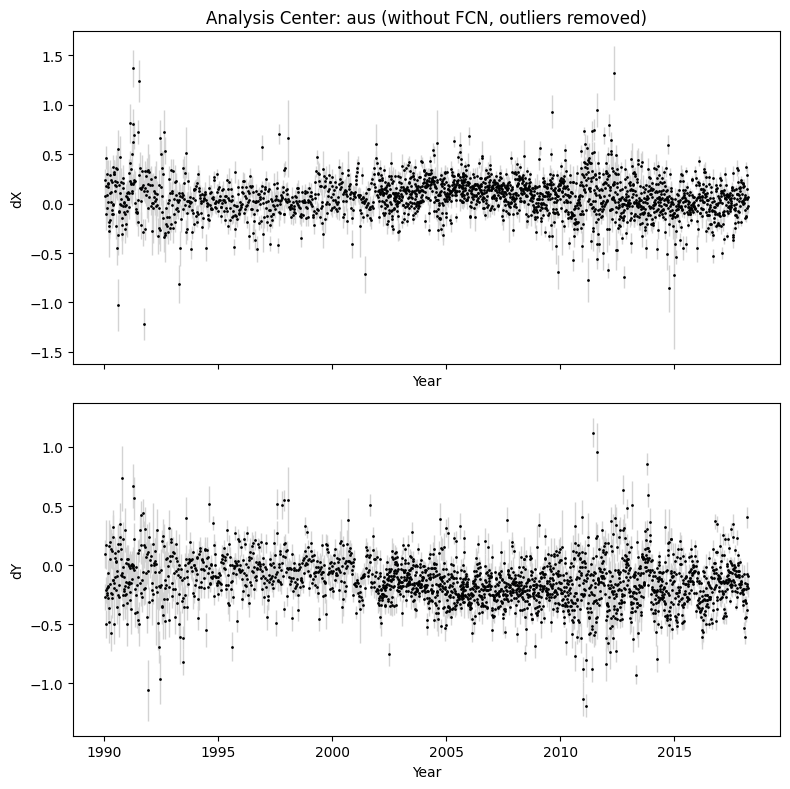

In [28]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - merged_dX['MJD']) / 365.242198781, merged_dX['dXnoFCN'], yerr=merged_dX['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: aus (without FCN, outliers removed)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - merged_dY['MJD']) / 365.242198781, merged_dY['dYnoFCN'], yerr=merged_dY['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan std dev - no FCN

In [29]:
%%time
tau_noFCN_dX, allanstd_noFCN_dX = allanself.oadev(merged_dX['dXnoFCN'].values,merged_dX['MJD'].values,merged_dX['sigma_dX'].values)

CPU times: total: 3min 40s
Wall time: 8min 51s


In [30]:
%%time
tau_noFCN_dY, allanstd_noFCN_dY = allanself.oadev(merged_dY['dYnoFCN'].values,merged_dY['MJD'].values,merged_dY['sigma_dY'].values)

CPU times: total: 3min 56s
Wall time: 9min


In [31]:
ci_noFCN_dX_low, ci_noFCN_dX_high = allanself.confidence_int(merged_dX['dXnoFCN'].values,merged_dX['sigma_dX'].values,allanstd_noFCN_dX,modified=False,overlapping=True,devtype='allan')
ci_noFCN_dY_low, ci_noFCN_dY_high = allanself.confidence_int(merged_dY['dYnoFCN'].values,merged_dY['sigma_dY'].values,allanstd_noFCN_dY,modified=False,overlapping=True,devtype='allan')

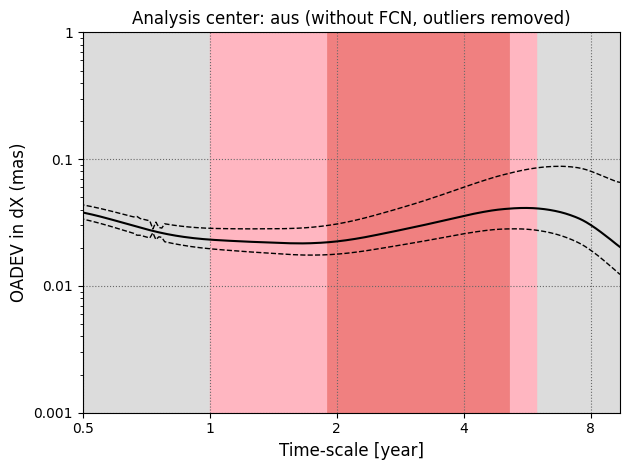

In [32]:
plt.figure()
# Calculate the slopes
slopes_noFCN_dX = np.diff(np.log10(allanstd_noFCN_dX)) / np.diff(np.log10(tau_noFCN_dX))
tau_noFCN_dX_year = [t/365.242198781 for t in tau_noFCN_dX]
# Plot allanstd

plt.plot(tau_noFCN_dX_year,allanstd_noFCN_dX,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (slopes_noFCN_dX < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (-0.25 <= slopes_noFCN_dX) & (slopes_noFCN_dX <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (slopes_noFCN_dX > 0.25),color='lightcoral',step='mid',linewidth=1)
# Plot confidence interval
plt.plot(tau_noFCN_dX_year, ci_noFCN_dX_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_noFCN_dX_year, ci_noFCN_dX_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dX (mas)', fontsize=12)
plt.title('Analysis center: aus (without FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_noFCN_dX_year))
plt.tight_layout()

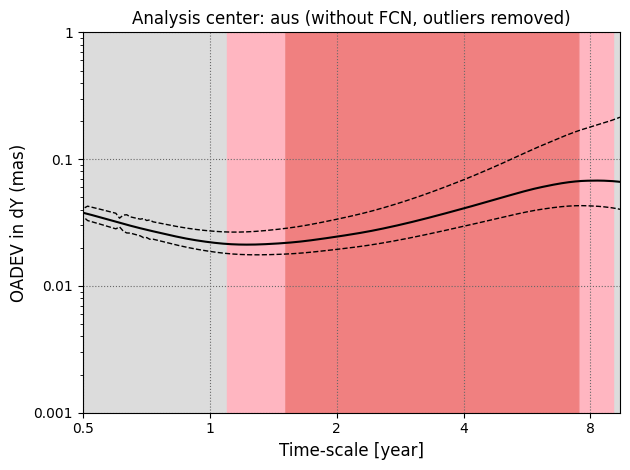

In [33]:
plt.figure()
# Calculate the slopes
slopes_noFCN_dY = np.diff(np.log10(allanstd_noFCN_dY)) / np.diff(np.log10(tau_noFCN_dY))
tau_noFCN_dY_year = [t/365.242198781 for t in tau_noFCN_dY]
# Plot allanstd

plt.plot(tau_noFCN_dY_year,allanstd_noFCN_dY,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (slopes_noFCN_dY < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (-0.25 <= slopes_noFCN_dY) & (slopes_noFCN_dY <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (slopes_noFCN_dY > 0.25),color='lightcoral',step='mid',linewidth=1)
# Plot confidence interval
plt.plot(tau_noFCN_dY_year, ci_noFCN_dY_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_noFCN_dY_year, ci_noFCN_dY_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dY (mas)', fontsize=12)
plt.title('Analysis center: aus (without FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_noFCN_dY_year))
plt.tight_layout()